# ML-MODEL-BUlDING-STEP-BY-STEP:-

Step:1:- importing all the required libraries

# Problem_Statement:- 

Insurance companies need to estimate medical costs for individuals based on their profile. This project builds a machine learning model to predict insurance charges using historical data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as see

Step:2:- import the data set

In [2]:
df = pd.read_csv(r"C:\Users\windows 10\Downloads\new_insurance_data.csv")

In [3]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [5]:
df.isna().sum().sum()

np.int64(52)

# EDA (Exploratory Data Analysis):-

As the null values are very low and not much impact on the module builiding we are removing them

Step:3:-

In [6]:
df.dropna(inplace = True)  # Changes Are Preminent

In [7]:
df.isna().sum().sum()

np.int64(0)

Handling the Duplicate Values:-

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# what if we have diplicate values:-
df.drop_duplicates(inplace = True)

In [10]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


As Mechine Learning Model only understands numerical values
--> first we should convert the "object" type columns to "Numeric" type
--> by using encoding (here we use label encoading):-

In [11]:
from sklearn.preprocessing import LabelEncoder
Le = LabelEncoder()
# we use these to convert "object" to "numeric"-
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = Le.fit_transform(df[col])

In [12]:
df.sample(5)

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
1074,55.0,1,37.300,0.0,0,51234.01552,27.0,987076.0,9953165.035,1.0,5.247590e+08,3,20630.28351
654,51.0,1,31.635,0.0,0,42322.35008,16.0,914300.0,3888709.970,1.0,1.012005e+08,1,9174.13565
662,51.0,0,34.100,0.0,0,31951.89945,12.0,909637.0,8419366.366,1.0,1.463992e+08,2,9283.56200
359,34.0,0,26.730,1.0,0,26144.64566,9.0,862161.0,3004786.819,1.0,7.107230e+07,2,5002.78270
260,34.0,1,34.210,0.0,0,30783.69237,5.0,831945.0,9076815.783,1.0,1.011024e+08,2,3935.17990


Now the Data is clean and good this is ready for the model building:-

Divide the Data into independent (X) and Dependent (Y):-

In [13]:
# HERE X IS INDEPENDENT DATA:-
X = df.drop(columns = ['charges']) # charges columns is 

In [14]:
# HERE Y ID DEPENDENT DATA:-
Y = df['charges']

In [15]:
X

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,0,35.530,0.0,1,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,1
1334,31.0,0,38.095,1.0,1,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,0
1335,52.0,1,34.485,3.0,1,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,1
1336,45.0,1,30.360,0.0,1,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,2


We should divide the data for training and testing for the model:-
--> To divide we are having an inbuild method from an library

In [16]:
from sklearn.model_selection import train_test_split
x_train ,x_test , y_train , y_test = train_test_split(X,Y,train_size = 0.80, random_state = 0)

In [17]:
x_train

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
510,44.0,1,34.320,1.0,0,16460.954610,22.0,883153.0,8.084459e+06,1.0,1.303457e+08,2
479,33.0,1,33.440,5.0,0,41495.241570,10.0,890208.0,2.395061e+06,1.0,1.055793e+08,2
316,29.0,0,24.600,2.0,0,5556.193100,12.0,827100.0,1.000335e+07,1.0,9.501109e+07,3
803,52.0,0,44.700,3.0,0,41327.384140,8.0,930768.0,2.155938e+06,1.0,2.025629e+08,3
528,18.0,0,29.165,0.0,0,8760.653674,10.0,903033.0,9.268380e+06,1.0,1.406115e+08,0
...,...,...,...,...,...,...,...,...,...,...,...,...
802,52.0,0,38.380,2.0,0,12992.139950,24.0,933863.0,4.075903e+06,1.0,2.061268e+08,0
875,60.0,1,24.320,0.0,0,41844.564980,8.0,940821.0,1.191697e+07,1.0,1.629471e+08,1
1261,37.0,1,34.100,4.0,1,52206.093400,30.0,1068775.0,6.842734e+07,2.0,1.648384e+09,3
595,46.0,1,33.345,1.0,0,37775.304960,8.0,902540.0,5.910532e+06,1.0,1.470959e+08,0


In [18]:
y_train

510      7147.472800
479      6653.788600
316      4529.477000
803     11411.685000
528      7323.734819
            ...     
802     11396.900200
875     12523.604800
1261    40182.246000
595      8334.457550
721     10141.136200
Name: charges, Length: 1029, dtype: float64

In [19]:
x_test

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
692,52.0,1,33.250,0.0,0,8130.290032,15.0,931543.0,4.265125e+06,1.0,1.474749e+08,0
355,31.0,0,23.600,2.0,0,19683.131830,19.0,849891.0,5.257252e+06,1.0,1.103433e+08,3
1050,31.0,1,29.810,0.0,1,24382.580560,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,2
512,44.0,1,38.060,1.0,0,41827.764410,21.0,877475.0,3.210070e+06,1.0,1.200297e+08,2
845,55.0,1,33.880,3.0,0,52155.958830,11.0,942142.0,7.683186e+06,1.0,1.969077e+08,2
...,...,...,...,...,...,...,...,...,...,...,...,...
793,33.0,1,42.460,1.0,0,36343.864730,11.0,933484.0,8.089966e+06,1.0,2.023595e+08,2
1098,33.0,1,22.705,0.0,0,42750.268640,14.0,1008841.0,1.076586e+07,1.0,5.188153e+08,1
54,18.0,1,23.320,1.0,0,28521.842900,12.0,740335.0,4.960146e+06,0.0,7.224537e+07,2
965,64.0,1,26.410,0.0,0,15996.028250,18.0,970279.0,8.909351e+06,1.0,2.576148e+08,0


Now every think is ready for the MODEL BUILDING:-

# Model Building:-

In [20]:
# CREATE A LINEAR REGRESSION MODEL:-
from sklearn.linear_model import LinearRegression 
le = LinearRegression ()

In [21]:
le.fit(x_train , y_train) # the training is done here

LinearRegression()

# Testing:-

In [22]:
model_answers = le.predict(x_test)

In [23]:
model_answers # THESE ARE THE PREDICTED ANSWERS FROM THE MODEL:-

array([11107.17283715,  6137.89265322, 18312.68376999,  8089.75539975,
       11936.27615387,  4922.42289246, 17202.34427979,  9456.08754466,
        4450.35241764,  3153.62788783,  2518.26964067,  5285.75646162,
       42098.97530636, 37666.51464953,  5967.32941929, 47628.17291828,
        1517.54473491, 12383.34341497,  2594.28314809, 12558.57666259,
       11426.53556088,  -162.13199863, 12478.67204877, 11511.50666598,
        -485.1143664 ,  4173.5878027 ,  4903.23482782,  4706.81340891,
       21338.87701008,  1822.7006789 ,  1388.39163125, 20297.93425391,
       29074.48775927, 13512.36894116,  9424.25146159,  5375.58800552,
        9855.77979393,  7313.96741425, 24956.10773917, 14315.25567466,
        7140.19532654, 10521.0466207 ,   890.5689652 , 45798.69602753,
       14648.11592632, 39750.20925218, 38280.80541861,  2668.42535054,
        6429.6108432 , 22741.13692831, 43650.6190245 , 14860.73847212,
         616.21980306,  1768.7874162 ,  5600.65146894, 36672.64933843,
      

In [24]:
# WE SHOULD COMPARE USING OUR VALUES:-
y_test

692      9722.76950
355      4931.64700
1050    19350.36890
512      7152.67140
845     11987.16820
           ...     
793     11326.71487
1098    21984.47061
54       1711.02680
965     14394.55790
971     14455.64405
Name: charges, Length: 258, dtype: float64

In [25]:
# we have a formula for comparing:- R2
from sklearn.metrics import r2_score
print(r2_score(model_answers,y_test)*100)

99.21903287305858


This means that the model has accuracy of 99%
-----> The Model is super good

# Testing using from user input:-

To Take Input from  the user:-

In [26]:
import numpy as np

print("Enter the following details to predict insurance charges")

age = float(input("Age: "))
sex = int(input("Sex (0 = Female, 1 = Male): "))
bmi = float(input("BMI: "))
children = float(input("Number of children: "))
smoker = int(input("Smoker (0 = No, 1 = Yes): "))
Claim_Amount = float(input("Claim Amount: "))
past_consultations = float(input("Past consultations: "))
num_of_steps = float(input("Number of steps: "))
Hospital_expenditure = float(input("Hospital expenditure: "))
NUmber_of_past_hospitalizations = float(input("Number of past hospitalizations: "))
Anual_Salary = float(input("Annual Salary: "))
region = int(input("Region (0,1,2,3): "))

Enter the following details to predict insurance charges


Age:  16.0
Sex (0 = Female, 1 = Male):  1
BMI:  32.33
Number of children:  0
Smoker (0 = No, 1 = Yes):  0
Claim Amount:  60000
Past consultations:  11
Number of steps:  8000
Hospital expenditure:  40000
Number of past hospitalizations:  3
Annual Salary:  0
Region (0,1,2,3):  0


To arrange all values in the Array:-

In [31]:
# Arrange inputs in same order as training
user_data = np.array([[age, sex, bmi, children, smoker,
                       Claim_Amount, past_consultations,
                       num_of_steps, Hospital_expenditure,
                       NUmber_of_past_hospitalizations,
                       Anual_Salary, region]])


for prediction:-

In [39]:
# Prediction
prediction = le.predict(user_data)

print("\nPredicted Insurance Charges:", prediction[0])


Predicted Insurance Charges: [-38714.32736493]


C:\Users\windows 10\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Regression Plot:-

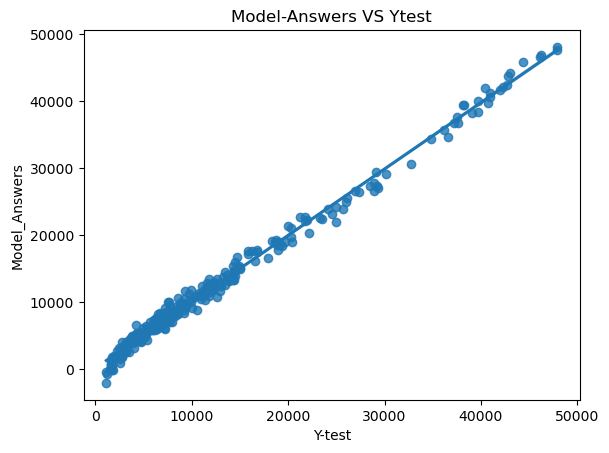

In [35]:
see.regplot(y = model_answers, x = y_test)
plt.xlabel('Y-test')
plt.ylabel('Model_Answers')
plt.title('Model-Answers VS Ytest')
plt.show()

In [40]:
# THE AVERAGE DIFFERENCE BETWEEN ACTUAL AND PREDICTED VALUES:- RMSE
from sklearn.metrics import mean_squared_error 
print('The Mean Square Error:- ' , np.sqrt(mean_squared_error(y_test , model_answers)))


The Mean Square Error:-  998.9655600640859
